<h1>1. Data Exploration<h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from IPython.display import display as disp

In [2]:
data_dict = {}
for i in range(1,5):
    df = pd.read_csv(f"CMAPSSData/train_FD00{str(i)}.txt", sep=" ", header=None)
    df = df.drop(columns=[26, 27])  # Remove the last two empty columns
    df.columns = ["Unit Number", "Time, In Cycles", "Setting 1", "Setting 2", "Setting 3"] + [f"Sensor {i}" for i in range(1, 22)]
    data_dict[i] = df

### Let's see if there are any redundant or uninformative features

In [3]:
for i in data_dict:
    print(f"Preview of data for FD00{str(i)}")
    disp(data_dict[i].describe())
    print("\n")

Preview of data for FD001


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400




Preview of data for FD002


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,...,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,131.082981,109.154746,23.998407,0.572056,94.046020,472.910207,579.672399,1419.971013,1205.442024,8.031986,...,266.069034,2334.557253,8066.597682,9.329654,0.023326,348.309511,2228.806358,97.756838,20.789296,12.473423
std,74.463862,69.180569,14.747376,0.310016,14.237735,26.389707,37.289399,105.946341,119.123428,3.613839,...,137.659507,128.068271,84.837950,0.749335,0.004711,27.754515,145.327980,5.364067,9.869331,5.921615
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,...,129.120000,2027.610000,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500
25%,68.000000,52.000000,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.655000,3.910000,...,131.520000,2387.900000,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546300
50%,131.000000,104.000000,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,...,183.200000,2388.080000,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200
75%,195.000000,157.000000,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,...,371.260000,2388.170000,8127.195000,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200
max,260.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,...,523.370000,2390.480000,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100




Preview of data for FD003


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,24720.000000,24720.000000,24720.000000,24720.000000,24720.0,24720.00,24720.000000,24720.000000,24720.000000,2.472000e+04,...,24720.000000,24720.000000,24720.000000,24720.000000,2.472000e+04,24720.000000,24720.0,24720.0,24720.000000,24720.000000
mean,48.631877,139.077063,-0.000024,0.000005,100.0,518.67,642.457858,1588.079175,1404.471212,1.462000e+01,...,523.050873,2388.071643,8144.202916,8.396176,3.000000e-02,392.566545,2388.0,100.0,38.988552,23.393024
std,29.348985,98.846675,0.002194,0.000294,0.0,0.00,0.523031,6.810418,9.773178,3.552786e-15,...,3.255314,0.158121,16.504118,0.060512,1.734759e-17,1.761459,0.0,0.0,0.248865,0.149234
min,1.000000,1.000000,-0.008600,-0.000600,100.0,518.67,640.840000,1564.300000,1377.060000,1.462000e+01,...,517.770000,2386.930000,8099.680000,8.156300,3.000000e-02,388.000000,2388.0,100.0,38.170000,22.872600
25%,23.000000,62.000000,-0.001500,-0.000200,100.0,518.67,642.080000,1583.280000,1397.187500,1.462000e+01,...,521.150000,2388.010000,8134.510000,8.360600,3.000000e-02,391.000000,2388.0,100.0,38.830000,23.296200
50%,47.000000,124.000000,-0.000000,-0.000000,100.0,518.67,642.400000,1587.520000,1402.910000,1.462000e+01,...,521.980000,2388.070000,8141.200000,8.398300,3.000000e-02,392.000000,2388.0,100.0,38.990000,23.391600
75%,74.000000,191.000000,0.001500,0.000300,100.0,518.67,642.790000,1592.412500,1410.600000,1.462000e+01,...,523.840000,2388.140000,8149.230000,8.437000,3.000000e-02,394.000000,2388.0,100.0,39.140000,23.483300
max,100.000000,525.000000,0.008600,0.000700,100.0,518.67,645.110000,1615.390000,1441.160000,1.462000e+01,...,537.400000,2388.610000,8290.550000,8.570500,3.000000e-02,399.000000,2388.0,100.0,39.850000,23.950500




Preview of data for FD004


,Unit Number,"Time, In Cycles",Setting 1,Setting 2,Setting 3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,...,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000
mean,124.325181,134.311417,23.999823,0.571347,94.031576,472.882435,579.420056,1417.896600,1201.915359,8.031626,...,266.735665,2334.427590,8067.811812,9.285604,0.023252,347.760029,2228.613283,97.751396,20.864333,12.518995
std,71.995350,89.783389,14.780722,0.310703,14.251954,26.436832,37.342647,106.167598,119.327591,3.622872,...,138.479109,128.197859,85.670543,0.750374,0.004685,27.808283,145.472491,5.369424,9.936396,5.962697
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,...,128.310000,2027.570000,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.930000,10.160000,6.084300
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,...,134.520000,2387.910000,8062.630000,8.648000,0.020000,330.000000,2212.000000,100.000000,10.940000,6.566100
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,...,183.450000,2388.060000,8083.810000,9.255600,0.020000,334.000000,2223.000000,100.000000,14.930000,8.960100
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,...,371.400000,2388.170000,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.000000,28.560000,17.135500
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,...,537.490000,2390.490000,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.000000,39.890000,23.885200


### There are some features with negligible standard deviation. We'll remove those because they don't provide any useful information.

In [4]:
for i in data_dict:
    df = data_dict[i]
    df = df.loc[:, df.std() != 0] #remove columns with zero variance
    data_dict[i] = df

### Next, we'll determine when each unit failed for each training set

In [5]:
cycles_to_fail = {}
for i in data_dict:
    df = data_dict[i]
    ctf = df.groupby("Unit Number")["Time, In Cycles"].max().reset_index()
    cycles_to_fail[i] = ctf

### Looking at the distribution of cycles to fail for each dataset

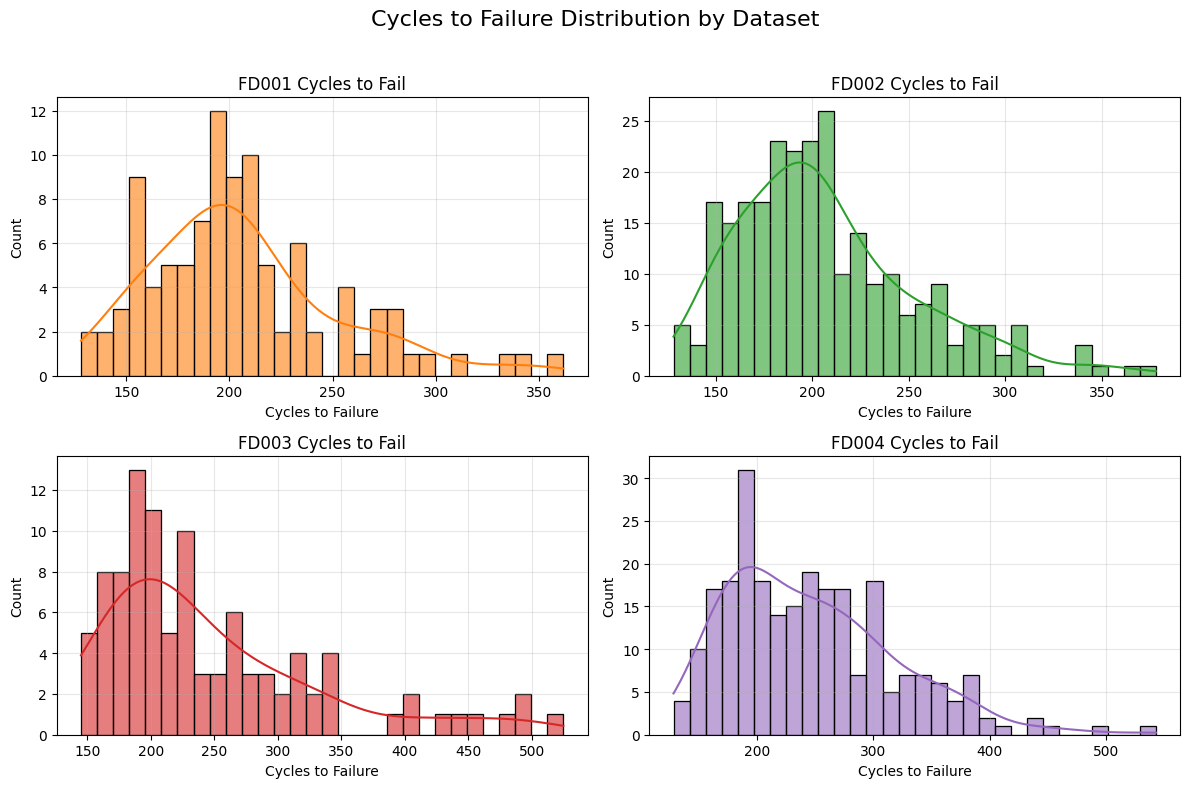

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for i in range(1, 5):
    ax = axs[(i - 1) // 2][(i - 1) % 2]
    sns.histplot(
        cycles_to_fail[i]["Time, In Cycles"],
        ax=ax,
        kde=True,
        bins=30,
        color=f"C{i}",
        edgecolor="black",
        alpha=0.6,
    )
    ax.set_title(f"FD00{i} Cycles to Fail")
    ax.set_xlabel("Cycles to Failure")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

fig.suptitle("Cycles to Failure Distribution by Dataset", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Now that we have an idea of the distribution for cycles to fail, we should look at the actual time series for a few engines. For simplicity, let's look at the turbine that has the maximum, minimum, and median cycles to failure for each dataset.

In [7]:
for i in cycles_to_fail:
    ctf = cycles_to_fail[i]
    print(f"Description for FD00{str(i)}:")
    disp(ctf.describe())

Description for FD001:


,Unit Number,"Time, In Cycles"
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


Description for FD002:


,Unit Number,"Time, In Cycles"
count,260.000000,260.000000
mean,130.500000,206.765385
std,75.199734,46.782198
min,1.000000,128.000000
25%,65.750000,174.000000
50%,130.500000,199.000000
75%,195.250000,230.250000
max,260.000000,378.000000


Description for FD003:


,Unit Number,"Time, In Cycles"
count,100.000000,100.00000
mean,50.500000,247.20000
std,29.011492,86.48384
min,1.000000,145.00000
25%,25.750000,189.75000
50%,50.500000,220.50000
75%,75.250000,279.75000
max,100.000000,525.00000


Description for FD004:


,Unit Number,"Time, In Cycles"
count,249.000000,249.00000
mean,125.000000,245.97992
std,72.024301,73.11080
min,1.000000,128.00000
25%,63.000000,190.00000
50%,125.000000,234.00000
75%,187.000000,290.00000
max,249.000000,543.00000


### Plucking out max, min, and median for each one

In [8]:
sample_units = {}
for i in cycles_to_fail:
    ctf = cycles_to_fail[i]
    sample_units[i] = (ctf.loc[ctf["Time, In Cycles"] == ctf["Time, In Cycles"].max(), "Unit Number"].values[0],
                       ctf.loc[ctf["Time, In Cycles"] == ctf["Time, In Cycles"].min(), "Unit Number"].values[0],
                       ctf.loc[ctf["Time, In Cycles"] == np.floor(ctf["Time, In Cycles"].median()), "Unit Number"].values[0])

### The data is high dimensional, so we'll just take a subset of each dataset. As a starting point, let's take the top 6 sensors with the highest variance for the max, min, and median units

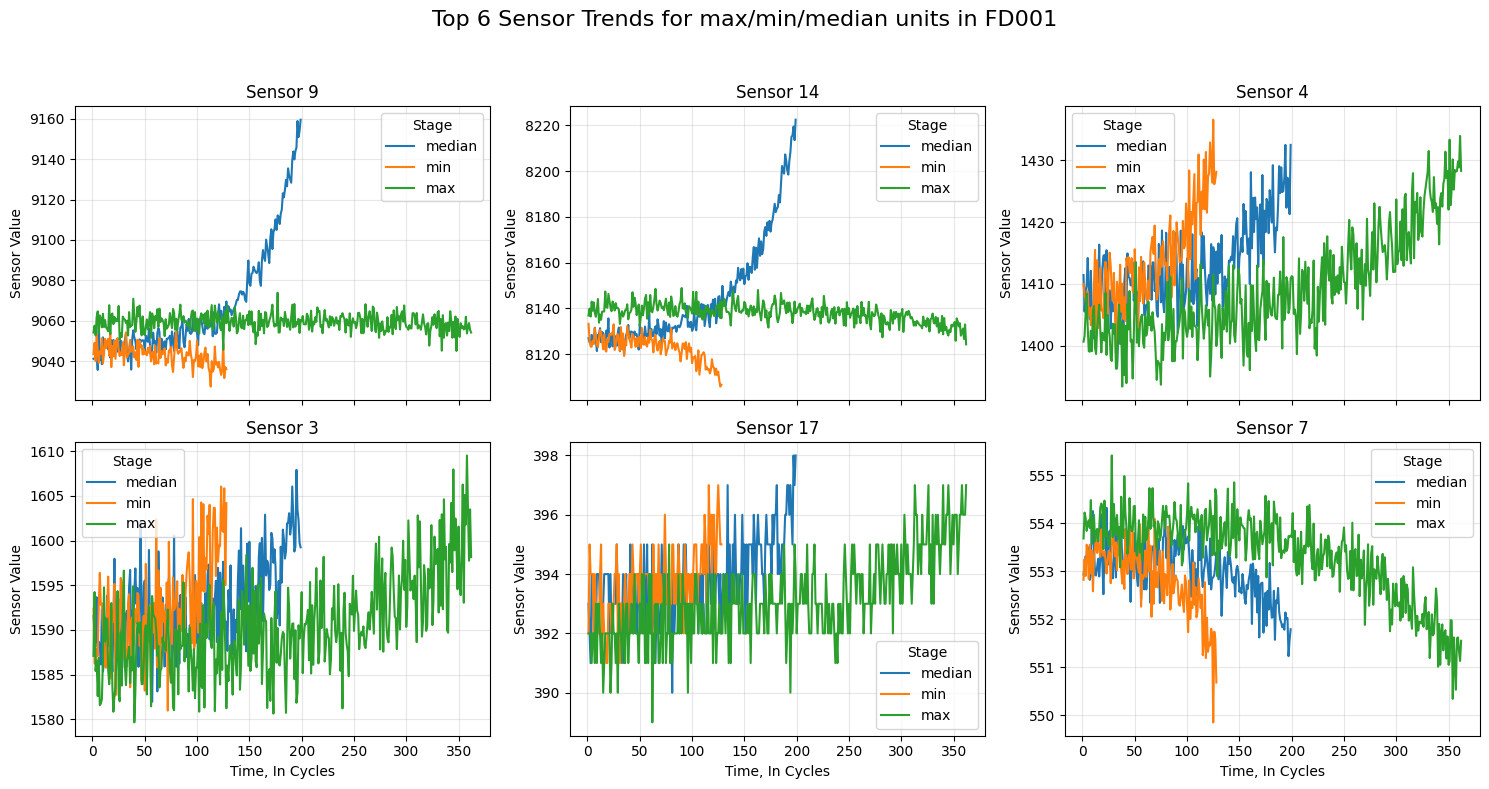

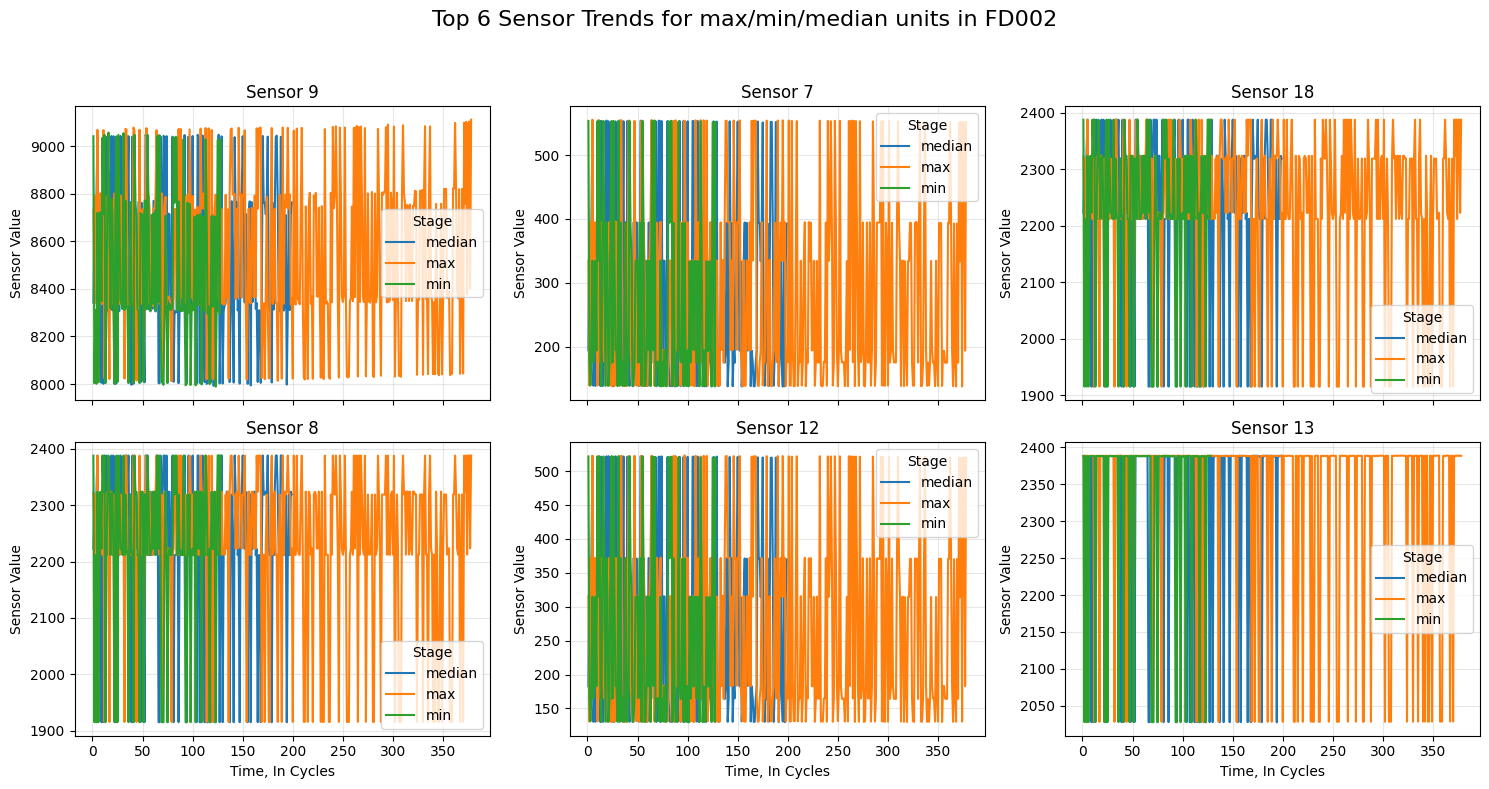

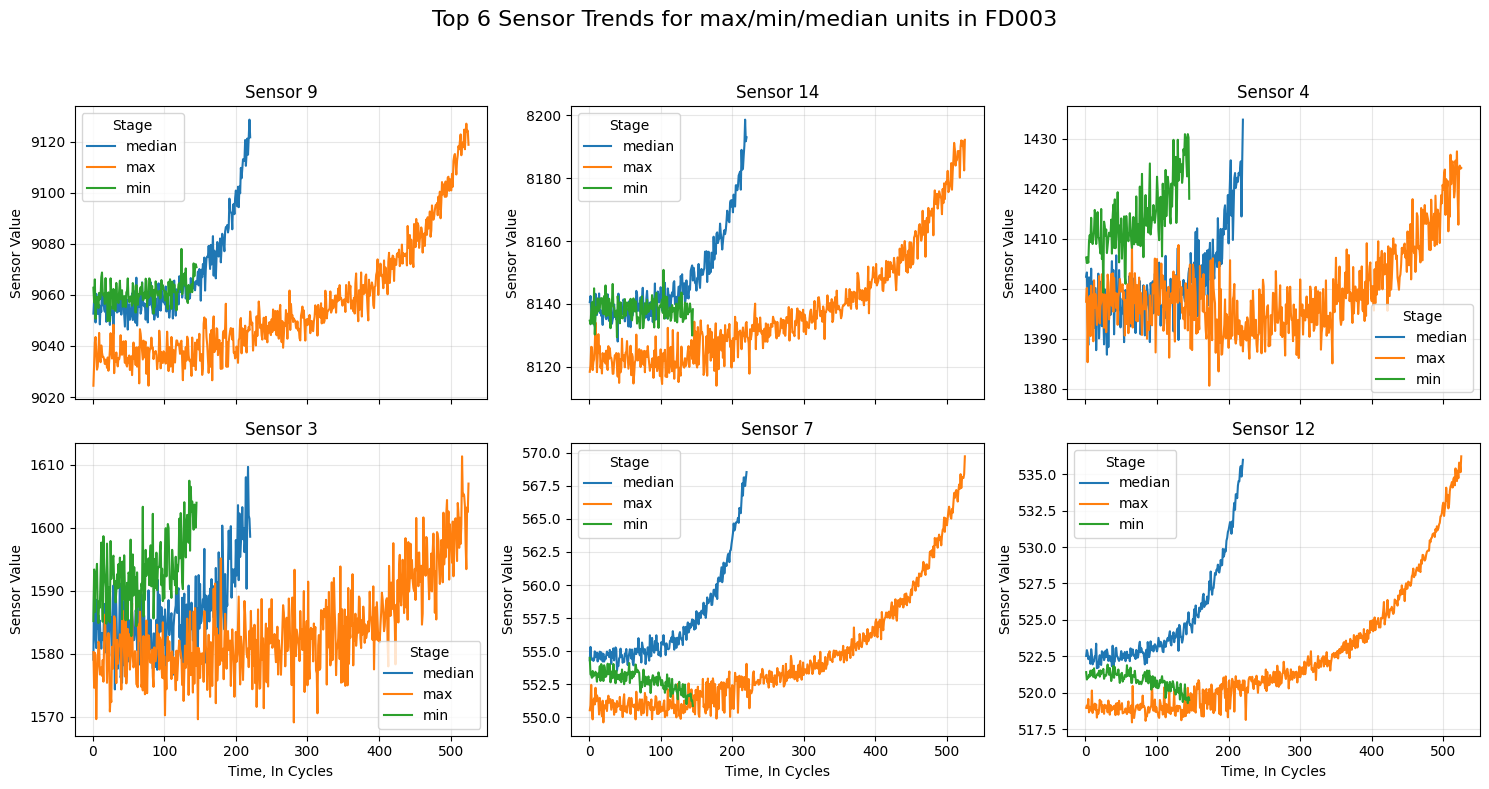

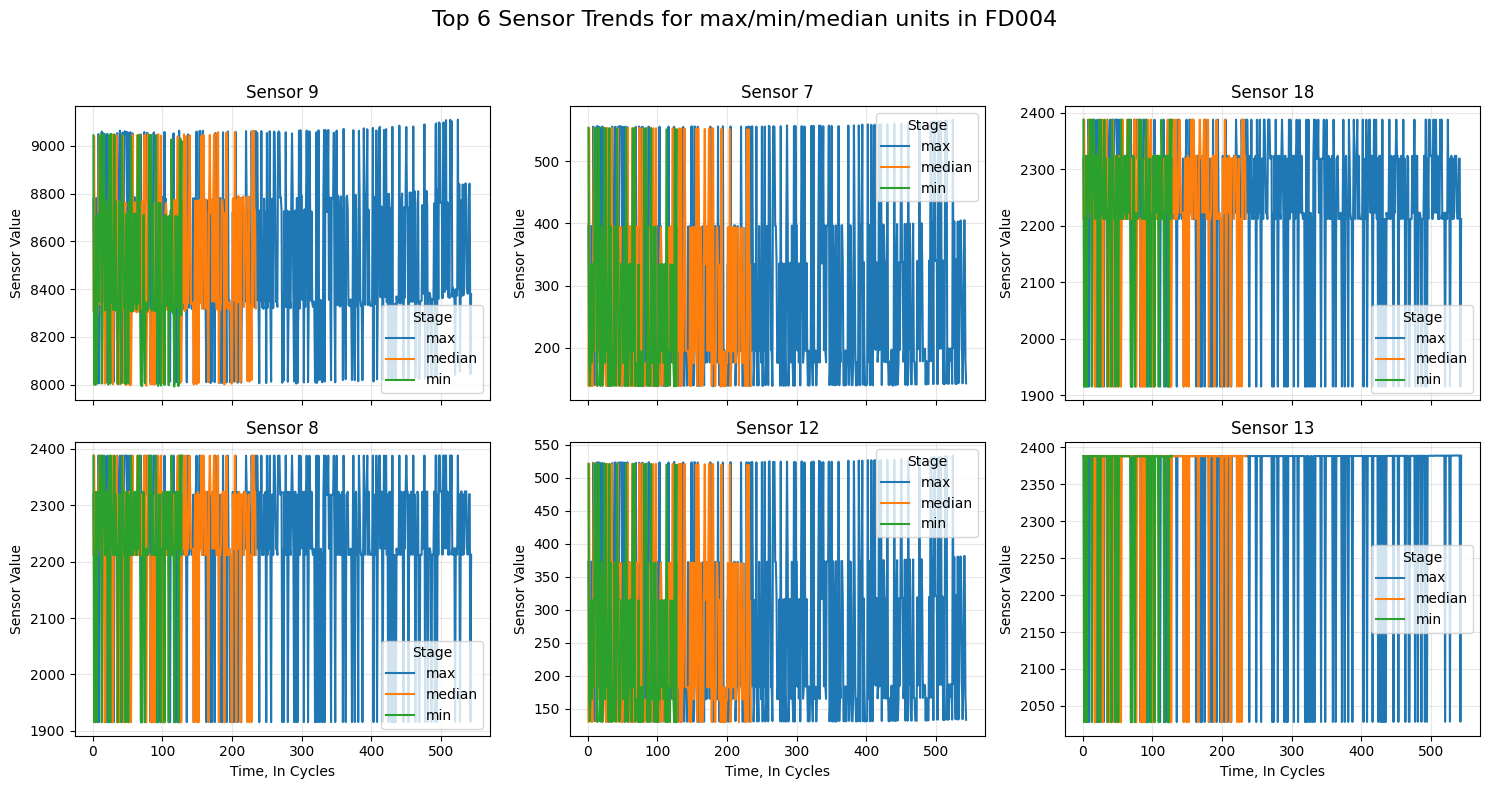

In [9]:
for i, units in sample_units.items():
    df = data_dict[i]
    selected_df = df[df["Unit Number"].isin(units)].copy() #slicing the dataframe to choose only max, min, and median units found in previous cell
    selected_df["Stage"] = selected_df["Unit Number"].map({
        units[0]: "max",
        units[1]: "min",
        units[2]: "median",
    }) # mapping the unit numbers to their respective stages for color coding the plots - "Stage" column determines color on the line plots

    sensor_cols = [col for col in df.columns if col.startswith("Sensor")]
    top_sensors = (
        df[sensor_cols].var().sort_values(ascending=False).head(6).index.tolist()
    ) #selecting the sensors that had the highest variance across the the max, min, and median units for each dataset

    fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    for j, col in enumerate(top_sensors):
        ax = axs[j // 3][j % 3]
        sns.lineplot(
            data=selected_df,
            x="Time, In Cycles",
            y=col,
            hue="Stage",
            ax=ax,
            palette="tab10",
        )
        ax.set_title(col)
        ax.set_xlabel("Time, In Cycles")
        ax.set_ylabel("Sensor Value")
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Top 6 Sensor Trends for max/min/median units in FD00{i}",
        fontsize=16,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Some key takeaways here:
1. The time series in FD001 AND FD003 have an exponential-looking trend, and FD002 and FD004 do not appear to have a trend
2. All the sensors are on a different scale, so it will be necessary to either scale or normalize the data
3. Sensors 9 and 7 appear appear in the "top 6" sensors for each dataset, so they could be imporant to pay attention to

### It will also be useful to look at how the different operational settings are varying with time.

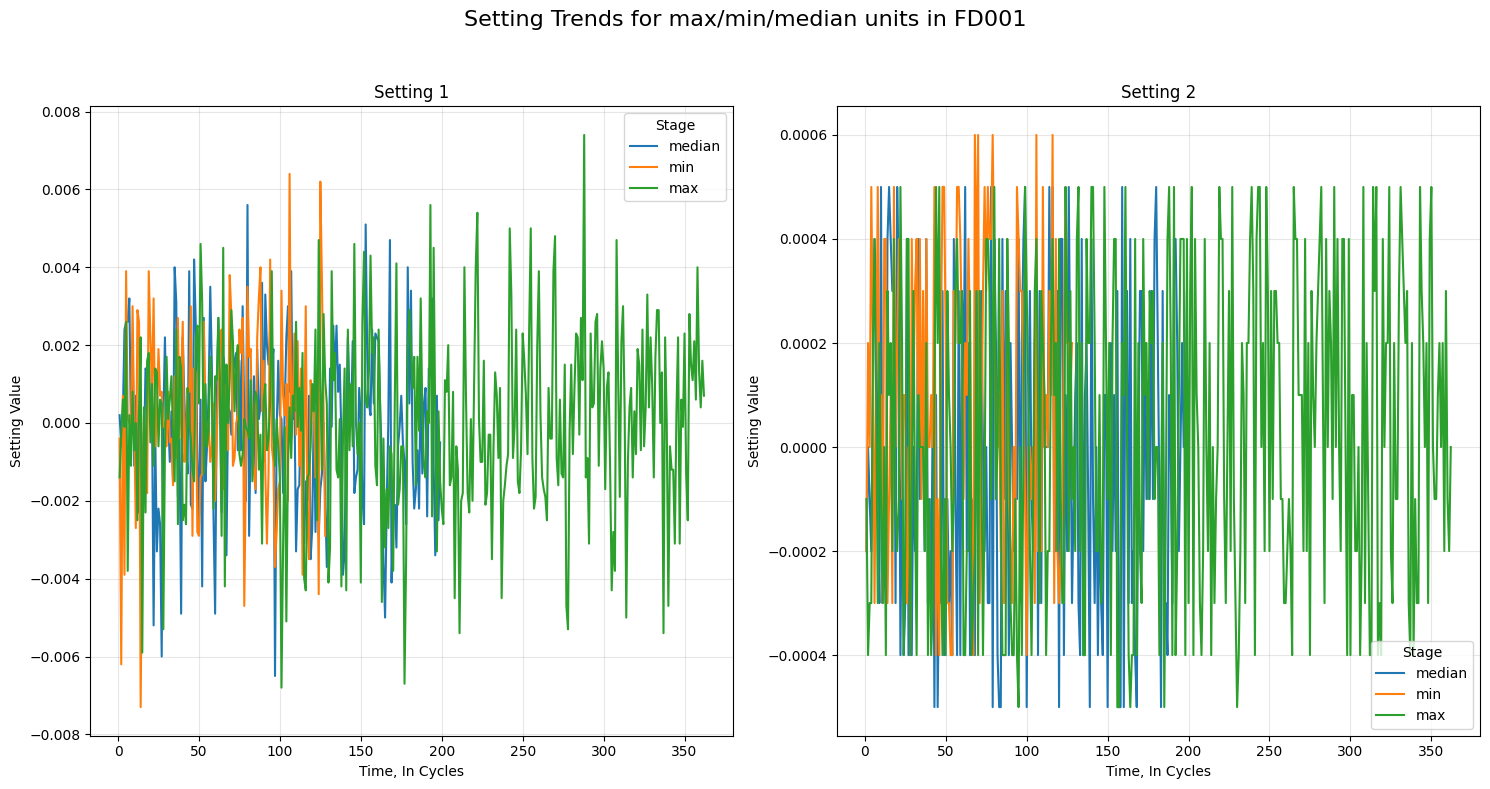

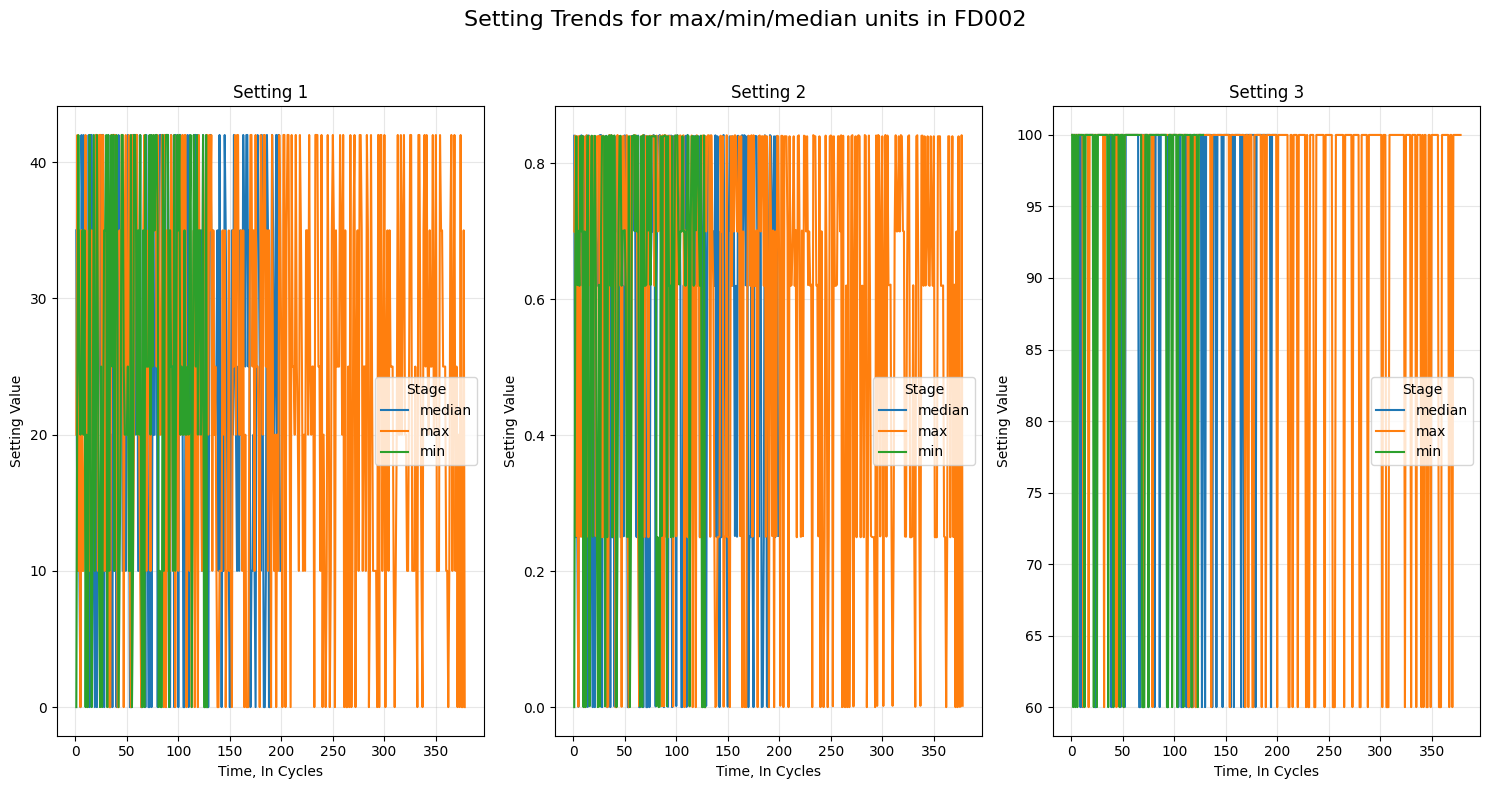

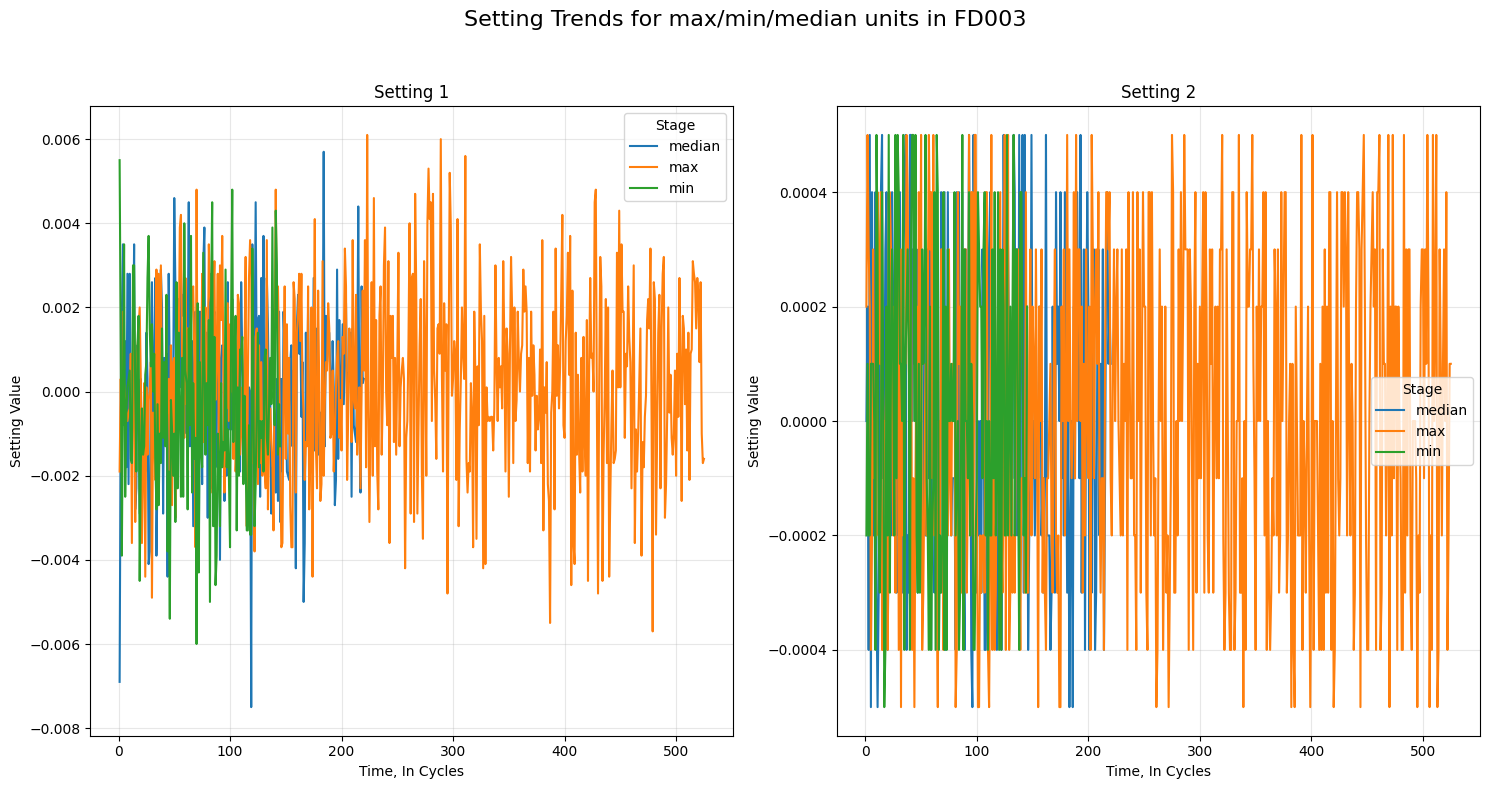

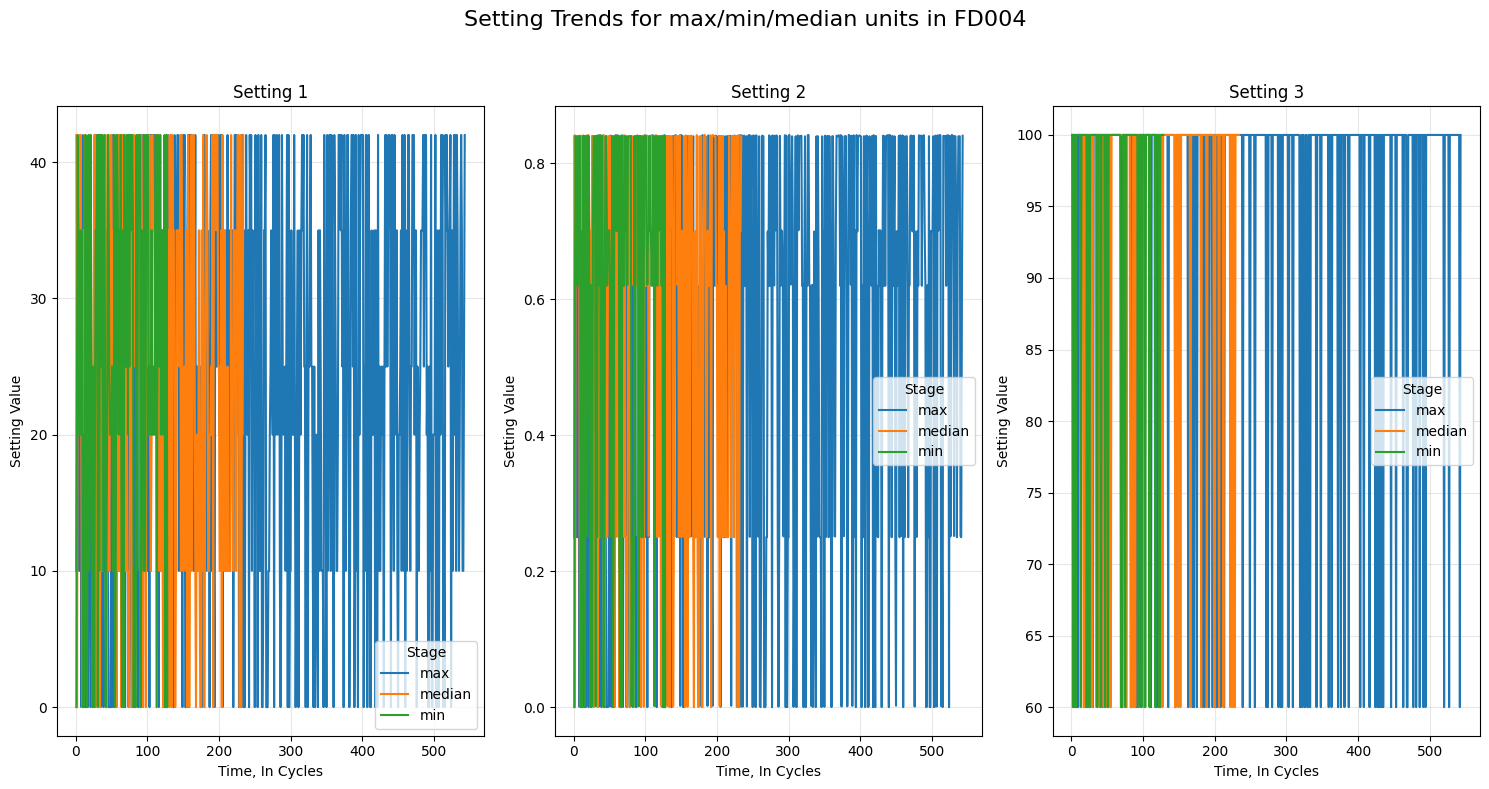

In [10]:
nrow = 1
for i, units in sample_units.items():
    df = data_dict[i]
    selected_df = df[df["Unit Number"].isin(units)].copy() #slicing the dataframe to choose only max, min, and median units found in previous cell
    selected_df["Stage"] = selected_df["Unit Number"].map({
        units[0]: "max",
        units[1]: "min",
        units[2]: "median",
    }) # mapping the unit numbers to their respective stages for color coding the plots - "Stage" column determines color on the line plots

    setting_cols = [col for col in df.columns if col.startswith("Setting")]
    fig, axs = plt.subplots(nrows=nrow, ncols=len(setting_cols), figsize=(15, 8), sharex=True)
    for j, col in enumerate(setting_cols):
        ax = axs[j]
        sns.lineplot(
            data=selected_df,
            x="Time, In Cycles",
            y=col,
            hue="Stage",
            ax=ax,
            palette="tab10",
        )
        ax.set_title(col)
        ax.set_xlabel("Time, In Cycles")
        ax.set_ylabel("Setting Value")
        ax.grid(alpha=0.3)

    fig.suptitle(
        f"Setting Trends for max/min/median units in FD00{i}",
        fontsize=16,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### FD001 and FD003 do not have data for Setting 3 because it was removed previously. It had a variance of zero.

<h1>2. Data Preparation<h1>

### As a starting point, let's compute the RUL

In [11]:
# for i in data_dict:
#     df = data_dict[i].copy()
#     df["RUL"] = df.groupby("Unit Number")["Time, In Cycles"].transform(lambda x: x.max() - x)
#     df["Dataset"] = f"FD00{i}" # adding a column to identify which dataset each row belongs to for combined analysis
#     data_dict[i] = df

### Now, to begin constructing pipelines. 

### Pipeline A:
- sensors are filtered based on Coefficient of Variation
- sensor values and operational settings are standardized
- RUL is capped at 125
- Lags computed at 1, 5, and 10

In [12]:
import preprocessing

In [13]:
dfa = preprocessing.pipeline_A(data_dict)

KeyError: 'Unit Number'

In [ ]:
# from preprocessing import drop_low_cv_sensors
# cv_filtered_data, sensors_to_drop = drop_low_cv_sensors(data_dict, threshold=0.05)
# print(sensors_to_drop)

In [ ]:
# lags = [1, 3, 5]
# RUL_cap = 125
# sensor_cols = [col for col in cv_filtered_data[1].columns if col.startswith("Sensor")]
# xa = {}
# ya = {}

# for i in cv_filtered_data:
#     df = cv_filtered_data[i].copy()

#     # creating lag features for each unit to avoid data leaks across units
#     for lag in lags:
#         df_lag = df.groupby("Unit Number")[sensor_cols].shift(lag)
#         df_lag.columns = [f"{col}_lag{lag}" for col in sensor_cols]

#         df = df.join(df_lag)
#     cv_filtered_data[i] = df.dropna()

In [ ]:
# for i in cv_filtered_data:
#     disp(cv_filtered_data[i].head())